1. **Nome(s): Jordano Furtado de Souza, Felipe Sala Carpes, Marcos Vinícius Silva**
2. **Matrícula(s): 2022101183, 2022102425, 2020100954**
3. **Curso(s): Engenharia de Computação**

### *É possível agrupar jogos automaticamente, baseando-se apenas em suas descrições, de modo que os grupos formados correspondam aos seus gêneros oficiais?*

# Trabalho Prático - Ciência de Dados

### Metodologia
1. Pré-processamento dos dados textuais;
2. Construção da matriz de TF-IDF;
3. Redução de dimensionalidade, via PCA;
4. Aplicação de ao menos dois algoritmos de agrupamento vistos na disciplina;
5. Validação da metodologia utilizada;
6. Interpretação dos resultados.


## 1. Pré-processamento dos dados textuais;

- Configuração do Ambiente: Importação das bibliotecas necessárias (Pandas, NLTK, Scikit-learn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

file_path = 'data/steam_games.csv'

nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

#seed fixa para efeito de reprodutibilidade 
seed = 10

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/felipecarpes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/felipecarpes/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


- Amostragem: Para otimizar o desempenho, optamos por reduzir o dataset através de uma amostragem aleatória simples, selecionando 15.000 instâncias.

In [2]:
def read_dataset(file_path):

    if not os.path.exists(file_path):
        print("ERRO: Arquivo de dados não encontrado!")
        return None

    df_complete = pd.read_csv(file_path)
    df_sample = df_complete.sample(n = 15000, random_state = seed)
    return df_sample

- Tratamento Textual: Filtramos elementos que não contribuem para a análise, incluindo símbolos, números e palavras repetitivas do domínio (ex: "game"), mantendo apenas o conteúdo possivelmente relevante para o agrupamento.

In [3]:
def clean_text(text):
    porter = PorterStemmer()
    custom_stops = {'game', 'play', 'player', 'gamer', 'http', 'https', 'www', 'href', 
                    'blank', 'rel', 'target', 'noreferr', 'dynamiclink'}
    final_stop_words = stop_words.union(custom_stops)
    
    text = str(text).lower()
    text = re.sub(r'<.*?>|http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = str(text)

    tokens = word_tokenize(text)
    tokens_processed = [
        porter.stem(word) for word in tokens 
        if word not in final_stop_words and len(word) > 2
    ]
    return " ".join(tokens_processed)

- O programa inicia carregando o dataset e filtrando as colunas, preservando apenas aquelas que serão utilizadas nas próximas etapas, e aplicando a limpeza do texto na coluna de descriçao.

In [4]:
df_bruto = read_dataset(file_path)

if df_bruto is not None:

    #seleciona colunas que serão utilizadas
    target_columns = [
        'appid', 'name', 'genres', 'description', 'short_description'
    ]
    df = df_bruto[target_columns].copy()

#aplica função de limpeza em cada um dos elementos da coluna de descrição dos jogos
game_descriptions_clean = df['description'].apply(clean_text)

## 2. Construção da matriz de TF-IDF;
- Nesta etapa, realizamos a vetorização das descrições, utilizando a técnica TF-IDF. O objetivo é transformar o texto em uma matriz numérica que pondere a relevância de cada termo, permitindo o cálculo de distâncias ou similaridades entre os jogos.
- Para refinar o vocabulário, ajustamos os parâmetros:
    - max_df: Elimina termos que aparecem em uma porcentagem excessiva dos documentos.
    - min_df: Descarta termos com frequência absoluta muito baixa, reduzindo a esparsidade e o ruído da matriz.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.8,min_df=10)
tfidf_matrix = vectorizer.fit_transform(game_descriptions_clean)
print(f"Formato da matriz: {tfidf_matrix.shape}")

Formato da matriz: (15000, 7630)


## 3. Redução de dimensionalidade, via PCA;
- Em seguida aplicamos uma versão do PCA que funciona para matrizes esparsas de forma eficiente, o LSA. Esta versão não centraliza os dados antes de realizar a decomposição dos valores singulares (SVD) evitando que a matriz de distância fique muito densa.
- O trecho de código abaixo foi adaptado da documentação da scikit-learn: https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html

In [6]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

#trecho de código de https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
lsa_pipeline = make_pipeline(TruncatedSVD(n_components=2000, random_state=seed), 
                              Normalizer(copy=False))
lsa=lsa_pipeline[0]

#Aplicando o LSA para o conjunto de dados
final_matrix = lsa_pipeline.fit_transform(tfidf_matrix)

print(f"original: {tfidf_matrix.shape}")
print(f"reduzido: {final_matrix.shape}")

original: (15000, 7630)
reduzido: (15000, 2000)


- Abaixo plotamos o gráfico de quanto dos dados foram preservados após a aplicação do PCA. Assim, foi possível perceber que aproximadamente 80% da informação foi preservada mesmo após a redução do número de colunas, indicando uma boa escolha na quantidade de features do nosso modelo.

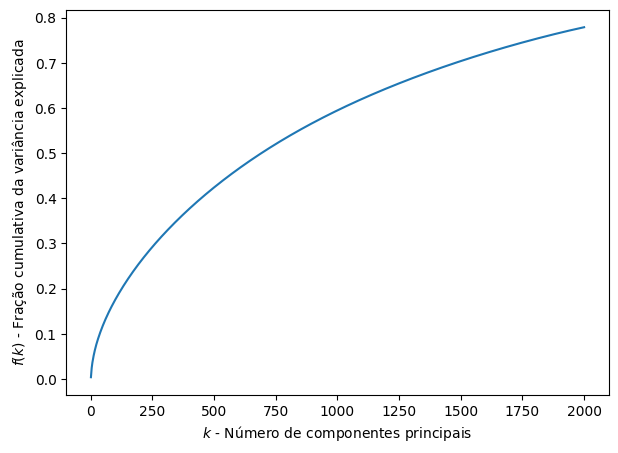

In [7]:
fig = plt.figure(figsize=(7, 5))
plt.plot([i for i in range(1, lsa.n_components + 1)], np.cumsum(lsa.explained_variance_ratio_))
plt.xlabel(r'$k$ - Número de componentes principais')
plt.ylabel(r'$f(k)$ - Fração cumulativa da variância explicada');

## 4. Aplicação de ao menos dois algoritmos de agrupamento vistos na disciplina;
### K-Means: Determinação do número de grupos (k)

- Um dos principais desafios na aplicação do algoritmo K-Means é a definição a parâmetro k (número de clusters) ideal para o problema. Para fundamentar essa escolha de forma objetiva, recorremos a métricas de validação interna. Essas métricas avaliam a qualidade da partição considerando apenas a estrutura dos dados (coesão interna e separação entre grupos), sem depender de rótulos externos.
- As métricas utilizadas foram:
    - Coeficiente de Silhueta: Mede o quão semelhante um objeto é ao seu próprio grupo em comparação aos outros grupos. Valores mais altos (próximos de 1) indicam melhor definição dos clusters.
    - Método do Cotovelo: Busca-se o ponto de inflexão (cotovelo) no gráfico, que indica o equilíbrio entre compressão dos dados e número de grupos.
    - Índice Calinski-Harabasz: Avalia a razão entre a dispersão entre grupos e a dispersão dentro de cada grupo. Valores mais altos indicam grupos mais densos e bem separados.
    - Índice Davies-Bouldin: Mede a similaridade média de cada cluster com seu cluster mais semelhante. Ao contrário das anteriores, valores menores indicam uma melhor separação entre os grupos.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

def visualize_metricas_plot(k_init,k_final):
    range_cluster=range(k_init, k_final)

    inertia = []
    silhouette = []
    calinski = []
    davies = []
    
    for n_clusters in range_cluster:
        #o algoritmo escolhe os primeiros centroides de forma sorteada, mas de forma que pontos que estão muito longe 
        #dos centros já escolhidos têm uma chance muito maior de serem escolhidos como o próximo centro.
        clusterer = KMeans(n_clusters=n_clusters, random_state=seed,init='k-means++', n_init = 10)
        cluster_labels = clusterer.fit_predict(final_matrix)

        # metrica do cotovelo
        inertia.append(clusterer.inertia_)
        
        silhouette_avg = silhouette_score(final_matrix, cluster_labels)
        silhouette.append(silhouette_avg)
        
        score_ch = calinski_harabasz_score(final_matrix, cluster_labels)
        calinski.append(score_ch)
        
        score_db = davies_bouldin_score(final_matrix, cluster_labels)
        davies.append(score_db)

        print(f"k = {n_clusters} | Sillhouette: {silhouette_avg:.6f} | CH: {score_ch:.2f} | DB: {score_db:.2f}")

    
    fig, axes = plt.subplots(4, 1, figsize=(10, 15))
    
   #grafico cotovelo
    axes[0].plot(range_cluster, inertia, marker='o')
    axes[0].set_title('Cotovelo')
    axes[0].set_xlabel('k')
    axes[0].set_ylabel('Inércia ')

    #gráfico silhueta
    axes[1].plot(range_cluster, silhouette, marker='o')
    axes[1].set_title('silhouette')
    axes[1].set_xlabel('k')
    axes[1].set_ylabel('silhouette (Maior é melhor)')
        
    #gráfico Calinski-Harabasz
    axes[2].plot(range_cluster, calinski, marker='o', color='orange')
    axes[2].set_title('Calinski-Harabasz Score')
    axes[2].set_xlabel('k')
    axes[2].set_ylabel('Score (Maior é melhor)')
    
    #gráfico Davies-Bouldin
    axes[3].plot(range_cluster, davies, marker='o', color='green')
    axes[3].set_title('Davies-Bouldin Index')
    axes[3].set_xlabel('k')
    axes[3].set_ylabel('Score (Menor é melhor)')
    
    plt.tight_layout()
    plt.show()

: 

- Para definir a quantidade de grupos, partimos do conhecimento sobre o domínimo da aplicação que a quantidade de gêneros de jogos deve ser entre 10 e 25. Com base nisso, testamos o algoritmo K-Means variando nesse intervalo, analisando os resultados conforme as métricas descritas anteriormente.
- Ao final, optamos pelo valor que apresentou o melhor equilíbrio geral entre as avaliações, evitando extremos.
    - **$K = 16$** 

In [ ]:
visualize_metricas_plot(10, 25)

k = 10 | Sillhouette: 0.006957 | CH: 55.54 | DB: 8.66
k = 11 | Sillhouette: 0.007406 | CH: 53.36 | DB: 8.37
k = 12 | Sillhouette: 0.007634 | CH: 50.87 | DB: 8.48


- O objetivo desta etapa é verificar se os jogos agrupados no mesmo cluster compartilham de fato um contexto temático similar.

- Para isso, examinamos os centróides de cada grupo. Como utilizamos TF-IDF, as palavras com os maiores pesos no vetor do centróide são aquelas que melhor descrevem o tópico daquele grupo. Por exemplo, espera-se que um cluster associado ao gênero "Corrida" apresente termos predominantes como "car", "race" e "velocity". Abaixo, listamos as 10 palavras de maior relevância para cada um dos 16 clusters formados.

## 5. Validação do Algoritmo K-Means
Os resultados apresentados neste agrupamento foram bastante satisfatórios, sendo possível destacar um mapeamento direto com gêneros clássicos de jogos, como:
- Cluster 11: A dominância de termos como 'race', 'car', 'track' e 'drift' cria uma separação clara para jogos de corrida.
- Cluster 12: Termos como 'war', 'unit', 'command' e 'tactic' delimitam claramente o gênero de Estratégia/RTS.
- Cluster 13: Palavras como 'logic', 'solve' e 'color' definem jogos de quebra-cabeça.

Também foi possível perceber que alguns grupos, como o Cluster 12, não foram mapeados para um gênero clássico, mas sim para um nicho bem preciso de 'Zombie', muitas vezes associado a jogos de sobrevivência. Já o Cluster 7 separou os jogos por modalidades e interações (multiplayer).

Por outro lado, notamos que alguns grupos ficaram ruidosos, como o Cluster 3. As palavras genéricas contidas nele poderiam ser incluídas na lista de stopwords em execuções futuras para refinar o resultado.

In [ ]:
#Imprime as 10 palavras de maiores peso para cada cluster
#adaptado de :https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
kmeans=KMeans(n_clusters=16, random_state=seed,init='k-means++', n_init = 10)
kmeans.fit_predict(final_matrix)
df['cluster_kmeans'] = kmeans.labels_

original_space_centroids = lsa.inverse_transform(kmeans.cluster_centers_)
order_centroids = original_space_centroids.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(0,16):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :10]:
        print(f"{terms[ind]} ", end="")
    print()
    

Cluster 0: girl beauti quot anim stori one time love school novel 
Cluster 1: new world get use time make build experi featur game 
Cluster 2: mode enemi weapon player multiplay fight onlin control team friend 
Cluster 3: dungeon monster gener item hero explor enemi level charact adventur 
Cluster 4: world magic hero power charact new enemi battl monster adventur 
Cluster 5: quot stori world mode new one time charact game level 
Cluster 6: ship space planet alien enemi galaxi weapon system new station 
Cluster 7: level platform challeng jump puzzl control collect get obstacl differ 
Cluster 8: zombi surviv weapon kill undead mode hord survivor level infect 
Cluster 9: card deck solitair battl collect power new uniqu oppon build 
Cluster 10: collector edit hidden wallpap exclus extra object standard bonu find 
Cluster 11: race car track drive mode vehicl racer speed driver drift 
Cluster 12: war unit battl campaign command mission armi enemi tactic new 
Cluster 13: puzzl solv level chal

A etapa final de validação qualitativa consiste em confrontar os grupos gerados pelo algoritmo com os gêneros oficialmente cadastrados na base de dados. No entanto, para garantir uma comparação justa e focada no conteúdo dos jogos, identificamos que certas etiquetas presentes no dataset introduzem ruído na análise, pois não descrevem mecânicas ou temas de jogabilidade.

Diante disso, optamos por filtrar as seguintes categorias da etapa de validação: 
- Indie: Embora presente em mais de 60% da base, este rótulo descreve o modelo de produção (estúdio independente) e não o gênero do jogo. Sua alta frequência mascara as distinções temáticas entre os clusters.
- Accounting, Documentary e Tutorial: Foram desconsiderados devido à irrelevância estatística, o que impede a formação de padrões detectáveis pelo algoritmo.
- Early Access e Free to Play: Estas etiquetas referem-se ao estado de lançamento e ao modelo de monetização, respectivamente, não possuindo correlação semântica com a descrição narrativa ou mecânica do jogo.

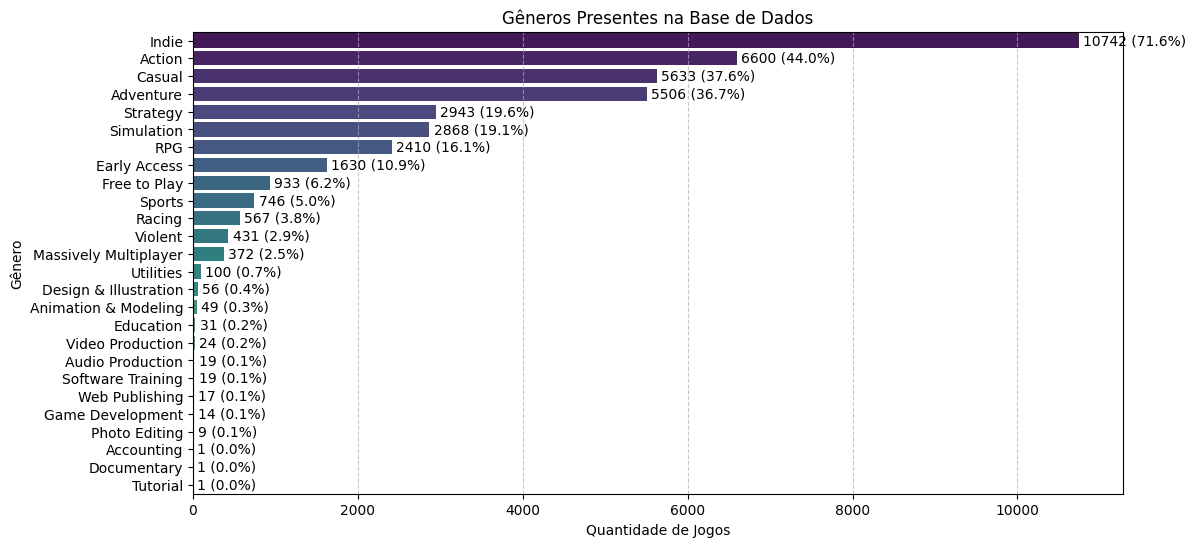

In [ ]:
genres_dummies = df['genres'].str.get_dummies(sep=';')

genre_counts = genres_dummies.sum().sort_values(ascending=False)
total_games = len(df)

plt.figure(figsize=(12, 6))
top_genres = genre_counts.head(26)

sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)

plt.title('Gêneros Presentes na Base de Dados')
plt.xlabel('Quantidade de Jogos')
plt.ylabel('Gênero')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(top_genres.values):
    plt.text(value + 50, index, f'{value} ({(value/total_games)*100:.1f}%)', va='center')

plt.show()

In [ ]:
remove_list = [
    'Indie', 
    'Casual', 
    'Early Access', 
    'Free to Play', 
    'Accounting', 
    'Documentary', 
    'Tutorial'
]

def clean_genre_tags(genre_str):
    
    current_tags = genre_str.split(';')
    kept_tags = [tag for tag in current_tags if tag.strip() not in remove_list]
    return ';'.join(kept_tags)

df['genres_clean'] = df['genres'].apply(clean_genre_tags)

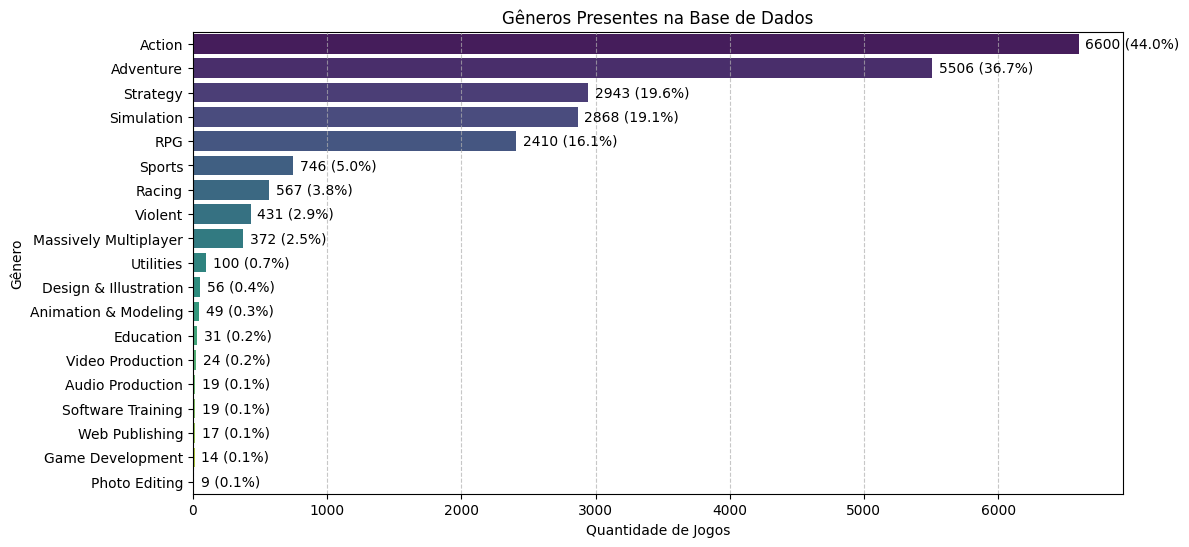

In [ ]:
genres_dummies = df['genres_clean'].str.get_dummies(sep=';')

genre_counts = genres_dummies.sum().sort_values(ascending=False)
total_games = len(df)

plt.figure(figsize=(12, 6))
top_genres = genre_counts.head(19)

sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)

plt.title('Gêneros Presentes na Base de Dados')
plt.xlabel('Quantidade de Jogos')
plt.ylabel('Gênero')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(top_genres.values):
    plt.text(value + 50, index, f'{value} ({(value/total_games)*100:.1f}%)', va='center')

plt.show()

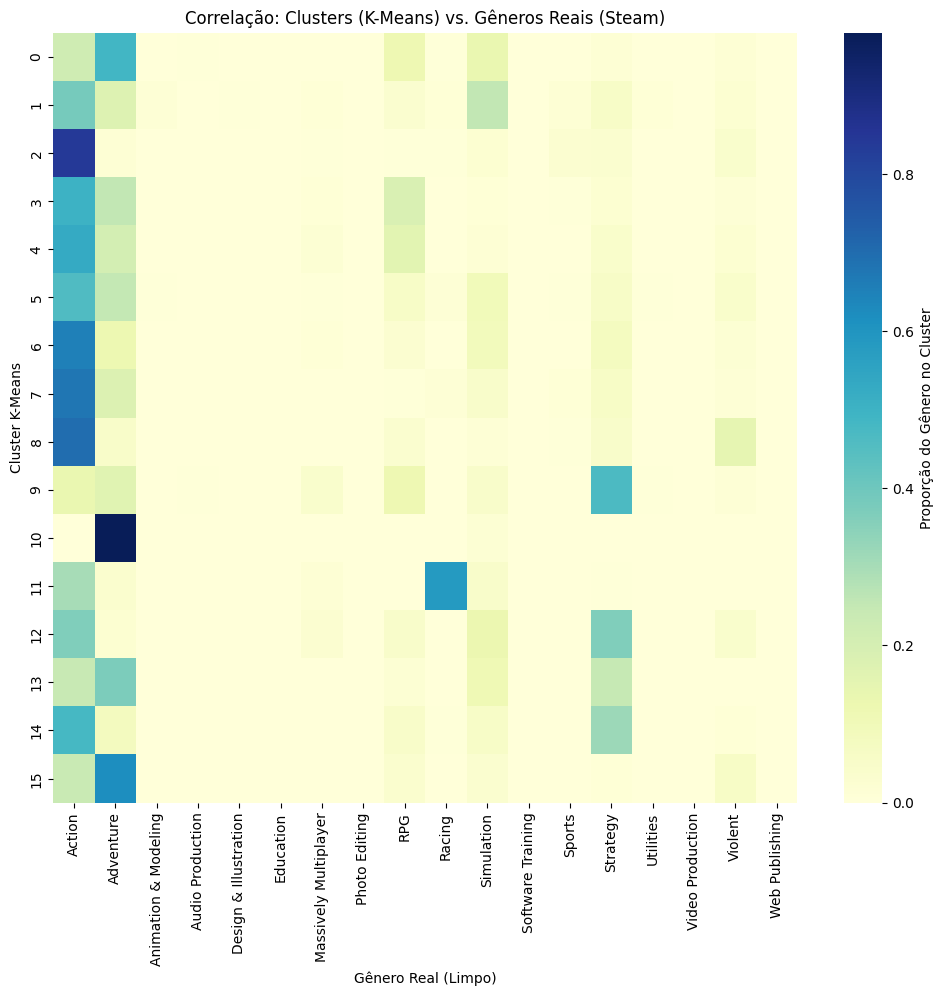

In [ ]:
df_validacao = df[df['genres_clean'] != ''].copy()

df_validacao['primary_genre'] = df_validacao['genres_clean'].apply(lambda x: x.split(';')[0])

crosstab = pd.crosstab(df_validacao['cluster_kmeans'], df_validacao['primary_genre'], normalize='index')

plt.figure(figsize=(12, 10))
sns.heatmap(crosstab, annot=False, cmap='YlGnBu', cbar_kws={'label': 'Proporção do Gênero no Cluster'})
plt.title('Correlação: Clusters (K-Means) vs. Gêneros Reais (Steam)')
plt.ylabel('Cluster K-Means')
plt.xlabel('Gênero Real (Limpo)')
plt.show()

Ao analisarmos o mapa de correlação entre os grupos do K-Means e os gêneros dos jogos, os resultados gerais parecem, num primeiro momento, insatisfatórios. O gráfico evidencia que 'Ação' e 'Aventura' dominam a maior parte dos clusters.

Podemos justificar esse comportamento não como uma falha do algoritmo, mas como uma dificuldade intrínseca aos dados: quando um jogo é cadastrado na Steam, ele quase invariavelmente recebe a categoria de ação ou aventura. Um jogo de tiro, de zumbi ou de guerra acabam todos caindo no mesmo rótulo de 'Ação'. Isso dificulta a comparação com o 'gabarito' real. Contudo, ao observarmos as palavras-chave de cada grupo, a relação com estilos de jogos específicos é visível, provando que o agrupamento funcionou semanticamente, mesmo que os gêneros oficiais não mostrem isso.

Um último destaque para nossa análise do K-Means é que, durante os testes, variamos os componentes do PCA e a quantidade inicial de jogos, e os resultados gerais foram muito parecidos. Visualmente, os grupos ficaram bem definidos, mas, quando comparados ao gabarito, não obtiveram desempenho superior ao mostrado acima.

## 4. Aplicação de ao menos dois algoritmos de agrupamento vistos na disciplina;
### Agrupamento Aglomerativo

A segunda técnica utilizada foi o Agrupamento Hierárquico Aglomerativo, que constrói os grupos fundindo os elementos mais similares passo a passo. Essa abordagem permite visualizar as relações de proximidade entre os jogos através de dendrogramas.

Para a validação dos resultados, replicamos a análise feita na etapa do K-Means. Utilizamos o mesmo intervalo de testes e as métricas Silhueta, Calinski-Harabasz e Davies-Bouldin (anteriormente definidas) para identificar o número de clusters que apresenta o melhor equilíbrio entre coesão e separação neste novo algoritmo

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

#trecho de código de https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
lsa_pipeline = make_pipeline(TruncatedSVD(n_components=500, random_state=seed), 
                              Normalizer(copy=False))
lsa=lsa_pipeline[0]

#Aplicando o LSA para o conjunto de dados
final_matrix = lsa_pipeline.fit_transform(tfidf_matrix)

print(f"original: {tfidf_matrix.shape}")
print(f"reduzido: {final_matrix.shape}")

original: (15000, 7630)
reduzido: (15000, 500)


A primeira grande diferença notada em comparação ao K-Means foi o comportamento do algoritmo Aglomerativo diante de muitas colunas. Os testes iniciais com alta dimensionalidade geraram clusters sobrepostos e métricas de qualidade negativas. Isso justificou a necessidade de alterar os parâmetros do PCA, reduzindo drasticamente o número de colunas para que o algoritmo conseguisse calcular as distâncias de forma eficaz e separar os grupos.

Iniciando análise do Agrupamento Aglomerativo...
k = 10 | Sillhouette: 0.002834 | CH: 68.26 | DB: 7.04
k = 11 | Sillhouette: 0.001924 | CH: 65.96 | DB: 6.62
k = 12 | Sillhouette: 0.001194 | CH: 63.72 | DB: 6.46
k = 13 | Sillhouette: 0.001000 | CH: 61.84 | DB: 6.48
k = 14 | Sillhouette: 0.001346 | CH: 60.23 | DB: 6.31
k = 15 | Sillhouette: 0.001597 | CH: 58.65 | DB: 6.32
k = 16 | Sillhouette: 0.001725 | CH: 57.16 | DB: 6.13
k = 17 | Sillhouette: 0.002422 | CH: 55.81 | DB: 6.30
k = 18 | Sillhouette: 0.002606 | CH: 54.48 | DB: 6.15
k = 19 | Sillhouette: 0.002409 | CH: 53.27 | DB: 6.01
k = 20 | Sillhouette: 0.003045 | CH: 52.16 | DB: 6.07
k = 21 | Sillhouette: 0.002894 | CH: 51.15 | DB: 5.98
k = 22 | Sillhouette: 0.002618 | CH: 50.21 | DB: 5.88
k = 23 | Sillhouette: 0.003158 | CH: 49.26 | DB: 6.04
k = 24 | Sillhouette: 0.002107 | CH: 48.30 | DB: 6.12


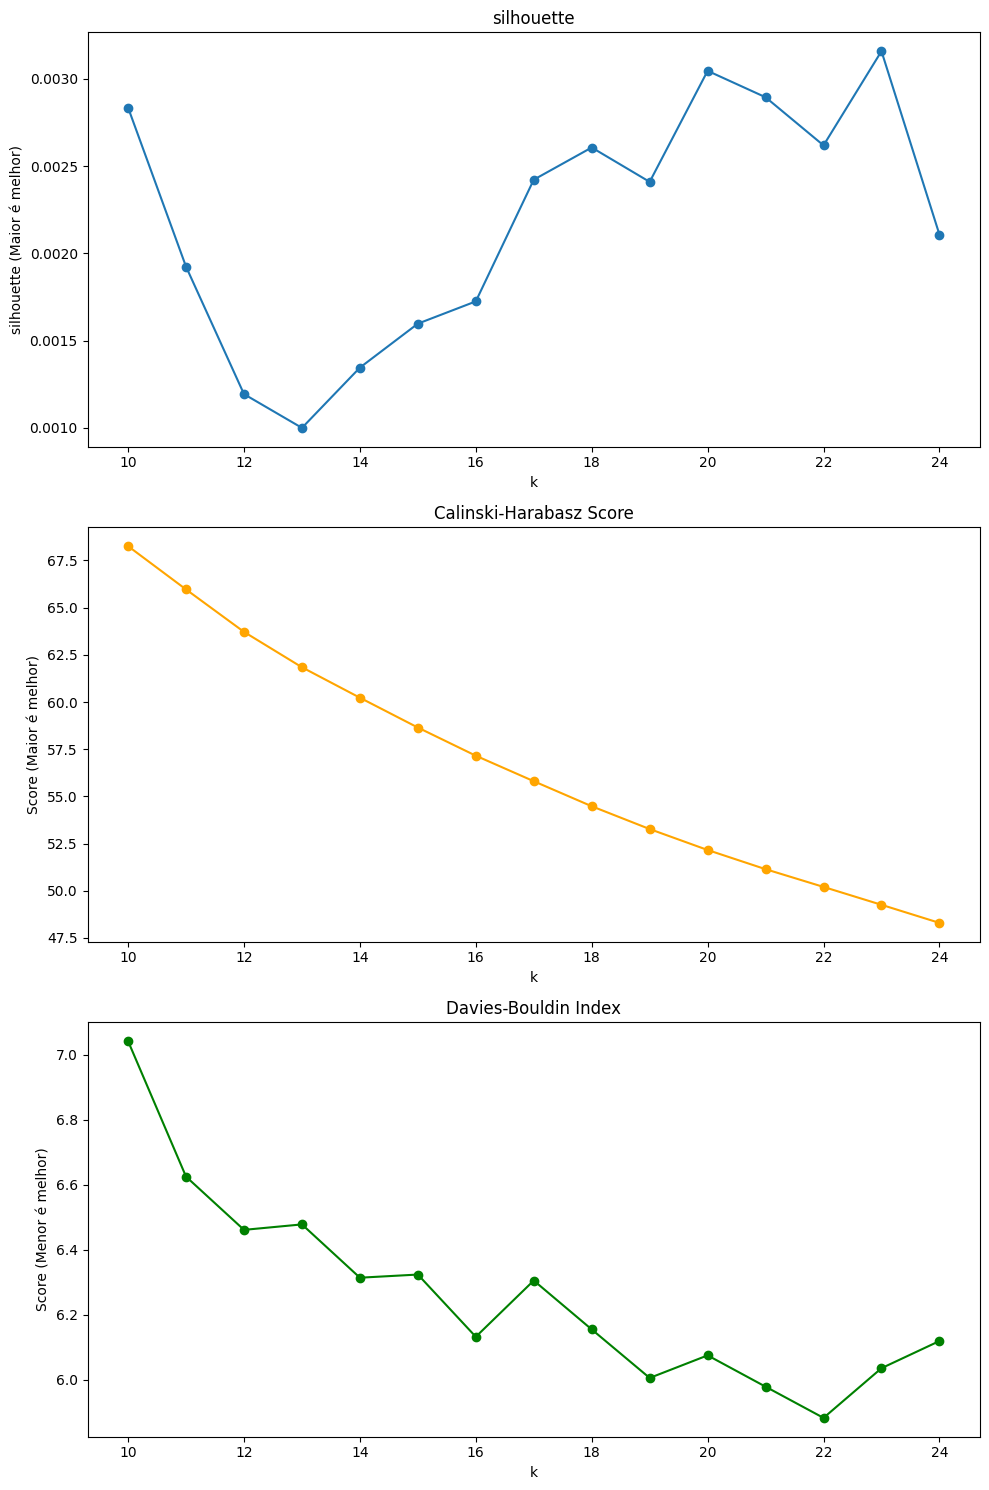

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score, davies_bouldin_score

range_cluster=range(10, 25)

silhouette = []
calinski = []
davies = []
print("Iniciando análise do Agrupamento Aglomerativo...")
for n_clusters in range_cluster:
    
    clusterer = AgglomerativeClustering(n_clusters=n_clusters,linkage='ward',metric='euclidean')
    cluster_labels = clusterer.fit_predict(final_matrix)

    silhouette_avg = silhouette_score(final_matrix, cluster_labels)

    silhouette_avg = silhouette_score(final_matrix, cluster_labels)
    silhouette.append(silhouette_avg)
    
    score_ch = calinski_harabasz_score(final_matrix, cluster_labels)
    calinski.append(score_ch)
    
    score_db = davies_bouldin_score(final_matrix, cluster_labels)
    davies.append(score_db)

    print(f"k = {n_clusters} | Sillhouette: {silhouette_avg:.6f} | CH: {score_ch:.2f} | DB: {score_db:.2f}")


fig, axes = plt.subplots(3, 1, figsize=(10, 15))

#gráfico silhueta
axes[0].plot(range_cluster, silhouette, marker='o')
axes[0].set_title('silhouette')
axes[0].set_xlabel('k')
axes[0].set_ylabel('silhouette (Maior é melhor)')
    
#gráfico Calinski-Harabasz
axes[1].plot(range_cluster, calinski, marker='o', color='orange')
axes[1].set_title('Calinski-Harabasz Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score (Maior é melhor)')

#gráfico Davies-Bouldin
axes[2].plot(range_cluster, davies, marker='o', color='green')
axes[2].set_title('Davies-Bouldin Index')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score (Menor é melhor)')

plt.tight_layout()
plt.show()

- Ao examinar as métricas, identificamos que o número ideal de clusters é 22. Foi neste ponto que o algoritmo conseguiu o melhor compromisso entre a separação dos grupos e a densidade interna dos dados.

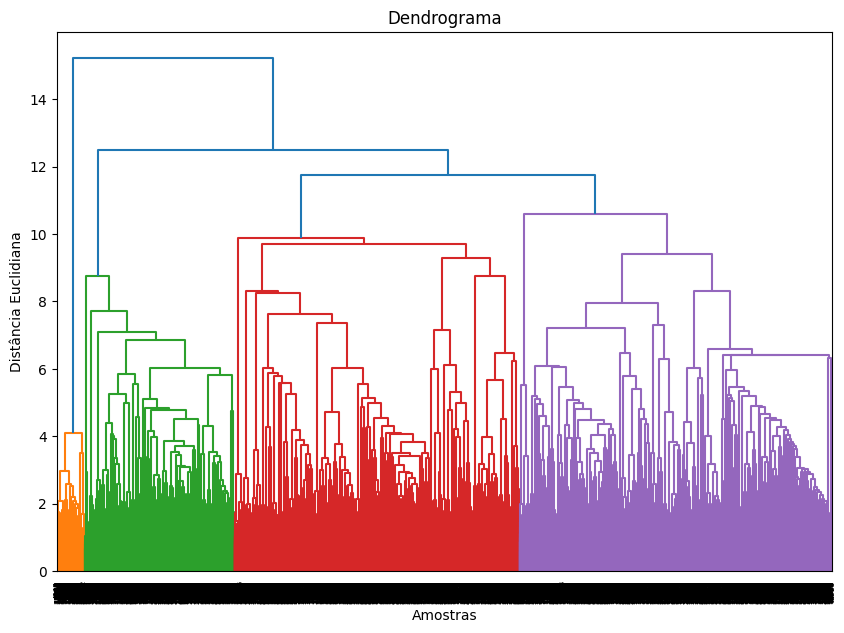

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(final_matrix, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title("Dendrograma")
plt.xlabel("Amostras")
plt.ylabel("Distância Euclidiana")
plt.show()

- Visualmente, o dendrograma sugere a existência de apenas 3 clusters densos e 1 menor. A escolha de k = 22 acaba por dispersar esses agrupamentos coesos em subgrupos artificiais. Essa fragmentação excessiva gera uma forte correlação com o padrão observado no K-Means, explicando por que ambos os algoritmos falharam em replicar a categorização binária simples do gabarito ('Ação' e 'Aventura').

## 5. Validação do Algoritmo Aglomerativo

Seguindo a mesma estratégia de validação utilizada no K-Means, vamos analisar as palavras-chave de cada cluster para verificar se, visualmente, os resultados apresentam padrões temáticos claros.

In [ ]:
clusterer = AgglomerativeClustering(n_clusters=22, linkage='ward', metric='euclidean')
clusterer.fit_predict(final_matrix)
df['cluster_aglome'] = clusterer.labels_

agglomerative_centroids = []

for i in range(22):
    points_in_cluster = final_matrix[clusterer.labels_ == i]
    
    if len(points_in_cluster) > 0:
        centroid = points_in_cluster.mean(axis=0)
    else:
        centroid = np.zeros(final_matrix.shape[1])
        
    agglomerative_centroids.append(centroid)

agglomerative_centroids = np.array(agglomerative_centroids)
original_space_centroids = lsa.inverse_transform(agglomerative_centroids)
order_centroids = original_space_centroids.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

print("-" * 50)
print("Principais palavras por Cluster (Aglomerativo):")
print("-" * 50)

for i in range(22):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :10]:
        print(f"{terms[ind]} ", end="")
    print()

--------------------------------------------------
Principais palavras por Cluster (Aglomerativo):
--------------------------------------------------
Cluster 0: stori world adventur puzzl find mysteri charact explor quot solv 
Cluster 1: level platform challeng get puzzl control quot mode featur time 
Cluster 2: unit war battl mission tank combat enemi new command tactic 
Cluster 3: citi build surviv farm world new resourc system villag craft 
Cluster 4: world experi new use game player mode featur music time 
Cluster 5: puzzl level color block tile solv challeng pictur logic relax 
Cluster 6: mode team multiplay player arena map onlin friend match local 
Cluster 7: hero new magic world spell charact battl rpg castl power 
Cluster 8: space planet alien star ship galaxi station explor new system 
Cluster 9: ship pirat fleet crew enemi sea battl space captain weapon 
Cluster 10: collector edit hidden bonu extra wallpap exclus find object standard 
Cluster 11: dungeon monster item hero ge

Os resultados do método Aglomerativo mostraram uma evolução em relação à separação feita pelo K-Means. Além de confirmar nichos bem definidos como Corrida (20), Zumbis (12) e Puzzle (5), o algoritmo conseguiu resolver melhor as sobreposições de gêneros.

O destaque foi a capacidade de quebrar o 'super-gênero' de Ação em vertentes distintas:

- Militar/Guerra: Isolado no Cluster 2.

- Tower Defense: Isolado no Cluster 13.

- Robôs/Futurista: Isolado no Cluster 17.

Também foi possível observar uma distinção precisa entre veículos espaciais (Cluster 8) e navais (Cluster 9), que compartilham vocabulário semelhante (como 'ship' e 'fleet') mas foram corretamente separados. O único grupo que apresentou baixa definição foi o Cluster 4, composto principalmente por palavras comuns (stopwords) e descrições genéricas que podem ser inseridas em uma próxima execução.

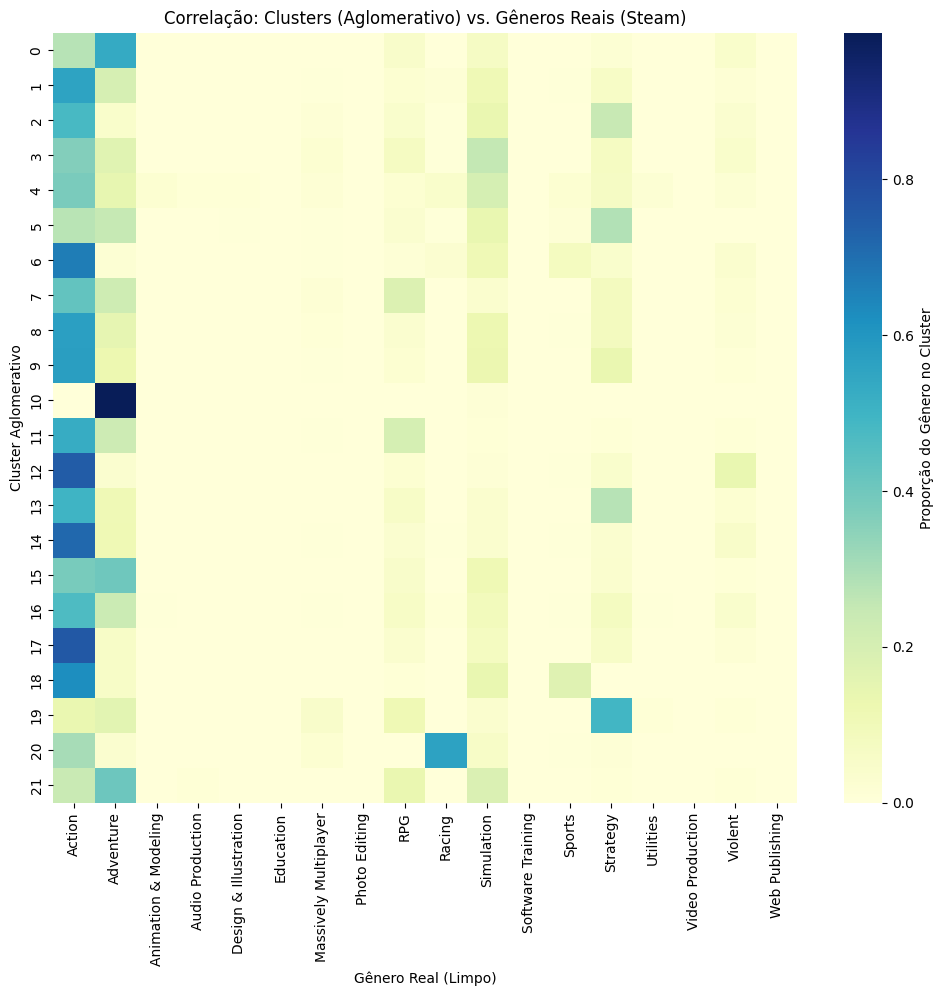

In [ ]:
df_validacao = df[df['genres_clean'] != ''].copy()

df_validacao['primary_genre'] = df_validacao['genres_clean'].apply(lambda x: x.split(';')[0])

crosstab = pd.crosstab(df_validacao['cluster_aglome'], df_validacao['primary_genre'], normalize='index')

plt.figure(figsize=(12, 10))
sns.heatmap(crosstab, annot=False, cmap='YlGnBu', cbar_kws={'label': 'Proporção do Gênero no Cluster'})
plt.title('Correlação: Clusters (Aglomerativo) vs. Gêneros Reais (Steam)')
plt.ylabel('Cluster Aglomerativo')
plt.xlabel('Gênero Real (Limpo)')
plt.show()

Nesta etapa de comparação com os gêneros, os resultados mantiveram o mesmo padrão limitado obtido pelo K-Means. Essa dificuldade de validação externa ocorre devido à forma como os jogos são cadastrados na plataforma, onde a repetição massiva de categorias amplas mascara os agrupamentos temáticos mais precisos identificados pelo algoritmo.

## 6. Interpretação dos resultados.

A análise comparativa revelou distinções importantes entre os algoritmos. O K-Means demonstrou maior robustez em alta dimensionalidade, processando eficazmente o conjunto com 2.000 colunas, sugerindo uma menor sensibilidade imediata à 'Maldição da Dimensionalidade' ou restrições computacionais em comparação ao método hierárquico. O Agrupamento Aglomerativo, por sua vez, exigiu que fosse feita uma maior redução de dimensionalidade(para 500 colunas) para operar satisfatoriamente. Entretanto, essa limitação foi compensada por uma qualidade semântica superior na especificidade dos grupos: o método foi capaz de isolar nichos temáticos específicos, como por exemplo os clusters de 'jogos de pirata' (cluster 9), 'survival craft' (cluster 15) e 'fantasy RPG' (cluster 7) que o K-Means tendeu a generalizar. Por fim, a consistência estrutural dos dados foi validada pela semelhança nos mapas de calor de ambos os algoritmos em relação à proporção de gêneros.